# Assignment 2 — Sanskrit-to-English Neural Machine Translation

**Course:** Natural Language Understanding

## 1. Introduction
Sanskrit is a low-resource, morphologically rich language: a single inflected word can carry
information that English expresses with several words, and 74.5% of the word types in the
training corpus occur exactly once. This notebook builds a **custom sequence-to-sequence
Transformer** (encoder–decoder with multi-head attention and beam search) that translates
Sanskrit sentences into English, trained **only on the provided dataset** (10,000 train /
1,000 dev / 1,000 test parallel pairs).

Design goals driven by the marking scheme (0.4·BLEU + 0.3·BERTScore + 0.15·time + 0.15·params):
* **Subword (BPE) tokenization** shared across both languages — handles the huge Sanskrit
  vocabulary and lets us **tie all embedding matrices** to reduce parameters.
* **Compact Transformer** (~6M parameters) — efficiency is 30% of the score.
* **Batched greedy decoding** for speed plus **beam search** for quality; both are timed.

**Pre-trained model disclosure:** the translation model itself is trained **from scratch** —
no pre-trained weights. The only pre-trained model used anywhere is `roberta-large`, loaded
internally by the official `bert-score` package **for evaluation only** (as the assignment
requires BERTScore). No external APIs are used.


## 2. Setup — install dependencies
All required packages (Colab already ships `torch`, `pandas`, `matplotlib`, `nltk`).

In [1]:
!pip install -q sentencepiece bert-score nltk sacremoses 2>/dev/null || pip install -q sentencepiece bert-score nltk
import torch, pandas, numpy
print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 60.6 MB/s eta 0:00:00
torch 2.11.0+cu128 | cuda: True


In [2]:
import os
os.environ['USE_TF'] = '0'      # bert-score/transformers: use PyTorch only
import io, time, math, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


### Data location
Running in **Google Colab**: the cell below mounts Google Drive and reads the CSVs from
`DATA_DIR` (edit it to the folder that holds the six CSV files).
Running **locally**: it falls back to the current directory.

In [3]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/NLU/Assignment2/'
except ImportError:
    DATA_DIR = './'
print("DATA_DIR =", DATA_DIR)

Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/NLU/Assignment2/


## 3. Load and explore the dataset
Each split comes as two CSVs (`*_sa` Sanskrit, `*_en` English) joined on `Source_id`.
Files carry a UTF-8 BOM, hence `encoding='utf-8-sig'`.

In [4]:
def load_pairs(en_file, sa_file):
    en_df = pd.read_csv(os.path.join(DATA_DIR, en_file), encoding='utf-8-sig')
    sa_df = pd.read_csv(os.path.join(DATA_DIR, sa_file), encoding='utf-8-sig')
    df = pd.merge(sa_df, en_df, on='Source_id')
    df['Sentence_sa'] = df['Sentence_sa'].astype(str).str.strip()
    df['Sentence_en'] = df['Sentence_en'].astype(str).str.strip()
    return df

train_df = load_pairs('train_en_10000.csv', 'train_sa_10000.csv')
dev_df   = load_pairs('dev_en_1000.csv',   'dev_sa_1000.csv')
test_df  = load_pairs('test_en_1000.csv',  'test_sa_1000.csv')
print('train:', train_df.shape, 'dev:', dev_df.shape, 'test:', test_df.shape)
train_df.head()

train: (10000, 3) dev: (1000, 3) test: (1000, 3)


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [5]:
# quick exploratory statistics
from collections import Counter
for name, df in [('train', train_df), ('dev', dev_df), ('test', test_df)]:
    sa_len = df['Sentence_sa'].str.split().str.len()
    en_len = df['Sentence_en'].str.split().str.len()
    print(f"{name:5s} | SA words: mean {sa_len.mean():5.1f} max {sa_len.max():3d} "
          f"| EN words: mean {en_len.mean():5.1f} max {en_len.max():3d} "
          f"| empty: {(df['Sentence_sa']=='').sum()+(df['Sentence_en']=='').sum()}")
sa_vocab = Counter(w for s in train_df['Sentence_sa'] for w in s.split())
en_vocab = Counter(w for s in train_df['Sentence_en'] for w in s.lower().split())
print(f"word-level vocab  SA: {len(sa_vocab):,}  EN: {len(en_vocab):,}")
print(f"SA singleton fraction: {sum(1 for c in sa_vocab.values() if c==1)/len(sa_vocab):.1%}"
      "  -> word-level modelling impossible, we need subwords (BPE)")

train | SA words: mean   9.7 max  55 | EN words: mean  12.6 max 116 | empty: 0
dev   | SA words: mean   9.4 max  37 | EN words: mean  12.2 max  47 | empty: 0
test  | SA words: mean   9.4 max  34 | EN words: mean  12.3 max  56 | empty: 0
word-level vocab  SA: 33,274  EN: 17,628
SA singleton fraction: 74.5%  -> word-level modelling impossible, we need subwords (BPE)


## 4. Preprocessing & Tokenization — joint SentencePiece BPE
* One **joint BPE model (8,000 merges)** trained on the *training split only* (both languages).
  A shared vocabulary lets the encoder embedding, decoder embedding and output projection
  share **one** weight matrix (3-way weight tying) — a large parameter saving.
* `character_coverage=1.0` so every Devanagari character is kept.
* Special tokens: `<pad>=0, <unk>=1, <s>=2, </s>=3`.

In [6]:
VOCAB_SIZE = 8000
SPM_PREFIX = 'spm_sa_en'
if not os.path.exists(SPM_PREFIX + '.model'):
    with io.open('spm_corpus.txt', 'w', encoding='utf-8') as f:
        for s in train_df['Sentence_sa']: f.write(s + '\n')
        for s in train_df['Sentence_en']: f.write(s + '\n')
    spm.SentencePieceTrainer.train(
        input='spm_corpus.txt', model_prefix=SPM_PREFIX, vocab_size=VOCAB_SIZE,
        model_type='bpe', character_coverage=1.0,
        pad_id=0, unk_id=1, bos_id=2, eos_id=3,
        pad_piece='<pad>', unk_piece='<unk>', bos_piece='<s>', eos_piece='</s>')
sp = spm.SentencePieceProcessor(model_file=SPM_PREFIX + '.model')
PAD, UNK, BOS, EOS = 0, 1, 2, 3
print('subword vocab size:', sp.get_piece_size())
print('sample:', sp.encode_as_pieces(train_df['Sentence_sa'][1]))

subword vocab size: 8000
sample: ['▁ग', 'ुर', 'ुः', '▁छात्र', 'ान्', '▁एकवारं', '▁पाठ', 'यति', '▁।']


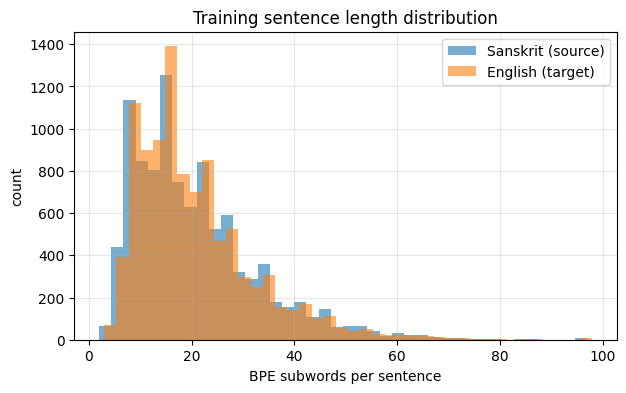

In [7]:
MAX_LEN = 96          # subword truncation length (>99.9% of sentences fit)
def encode_pairs(df):
    src = [sp.encode(s)[:MAX_LEN] + [EOS] for s in df['Sentence_sa']]
    tgt = [[BOS] + sp.encode(s)[:MAX_LEN] + [EOS] for s in df['Sentence_en']]
    return src, tgt

train_src, train_tgt = encode_pairs(train_df)
dev_src,   dev_tgt   = encode_pairs(dev_df)
test_src,  test_tgt  = encode_pairs(test_df)

# BPE-dropout (subword regularization): a fresh stochastic segmentation of the
# training data is drawn every epoch, so the model cannot memorise one fixed
# subword sequence per sentence - the key anti-overfitting device on 10k pairs.
def resample_train():
    src = [sp.encode(s, enable_sampling=True, alpha=0.1, nbest_size=-1)[:MAX_LEN] + [EOS]
           for s in train_df['Sentence_sa']]
    tgt = [[BOS] + sp.encode(s, enable_sampling=True, alpha=0.1, nbest_size=-1)[:MAX_LEN] + [EOS]
           for s in train_df['Sentence_en']]
    return src, tgt

plt.figure(figsize=(7,4))
plt.hist([len(s) for s in train_src], bins=40, alpha=.6, label='Sanskrit (source)')
plt.hist([len(t) for t in train_tgt], bins=40, alpha=.6, label='English (target)')
plt.xlabel('BPE subwords per sentence'); plt.ylabel('count')
plt.title('Training sentence length distribution'); plt.legend(); plt.grid(alpha=.3); plt.show()

### Length-bucketed batching
Sentences are sorted by source length before batching so each mini-batch contains
similar-length sentences — this minimises `<pad>` tokens and speeds up training.
Batch **order** is shuffled every epoch for stochasticity.

In [8]:
BATCH = 64
def make_batches(src, tgt, batch_size, shuffle=True):
    idx = sorted(range(len(src)), key=lambda i: len(src[i]))
    batches = [idx[i:i+batch_size] for i in range(0, len(idx), batch_size)]
    if shuffle: random.shuffle(batches)
    return batches

def pad_batch(seqs):
    m = max(len(s) for s in seqs)
    return torch.tensor([s + [PAD]*(m-len(s)) for s in seqs], dtype=torch.long)

## 5. Architecture — custom Transformer encoder–decoder

| Component | Choice |
|---|---|
| Embeddings | 256-d, **shared** source/target/output (weight tying) |
| Encoder | 3 pre-norm layers, 4-head self-attention, GELU FFN (512) |
| Decoder | 3 pre-norm layers, masked self-attention + **cross-attention** over encoder memory |
| Positional info | fixed sinusoidal positional encoding |
| Regularization | dropout 0.2 everywhere, label smoothing 0.1 |
| Decoding | batched greedy **and** length-normalised beam search (beam 5, α = 0.6) |

The encoder turns the Sanskrit subword sequence into contextual memory vectors; each decoder
step attends to its own past (causal mask) **and** to the encoder memory (cross-attention),
then a linear layer tied to the embedding matrix predicts the next English subword.

In [9]:
class PositionalEncoding(nn.Module):
    """Adds fixed sinusoidal position information to the token embeddings."""
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class EncoderLayer(nn.Module):
    """Pre-norm: LayerNorm -> self-attention -> residual, then LayerNorm -> FFN -> residual."""
    def __init__(self, d, h, ff, p):
        super().__init__()
        self.attn = nn.MultiheadAttention(d, h, dropout=p, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(p), nn.Linear(ff, d))
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.drop = nn.Dropout(p)
    def forward(self, x, pad_mask):
        h = self.n1(x)
        a, _ = self.attn(h, h, h, key_padding_mask=pad_mask, need_weights=False)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.n2(x)))
        return x

class DecoderLayer(nn.Module):
    """Masked self-attention over generated prefix + cross-attention over encoder memory."""
    def __init__(self, d, h, ff, p):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d, h, dropout=p, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d, h, dropout=p, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Dropout(p), nn.Linear(ff, d))
        self.n1, self.n2, self.n3 = nn.LayerNorm(d), nn.LayerNorm(d), nn.LayerNorm(d)
        self.drop = nn.Dropout(p)
    def forward(self, x, mem, tgt_mask, tgt_pad, src_pad):
        h = self.n1(x)
        a, _ = self.self_attn(h, h, h, attn_mask=tgt_mask, key_padding_mask=tgt_pad, need_weights=False)
        x = x + self.drop(a)
        h = self.n2(x)
        a, _ = self.cross_attn(h, mem, mem, key_padding_mask=src_pad, need_weights=False)
        x = x + self.drop(a)
        x = x + self.drop(self.ff(self.n3(x)))
        return x

class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab, d=256, h=4, ff=512, enc_layers=3, dec_layers=3, p=0.2):
        super().__init__()
        self.d = d
        self.emb = nn.Embedding(vocab, d, padding_idx=PAD)
        self.pos = PositionalEncoding(d)
        self.enc = nn.ModuleList([EncoderLayer(d, h, ff, p) for _ in range(enc_layers)])
        self.dec = nn.ModuleList([DecoderLayer(d, h, ff, p) for _ in range(dec_layers)])
        self.enc_norm, self.dec_norm = nn.LayerNorm(d), nn.LayerNorm(d)
        self.drop = nn.Dropout(p)
        self.out = nn.Linear(d, vocab, bias=False)
        self.out.weight = self.emb.weight            # 3-way weight tying
        # small-variance init keeps the tied output logits well-scaled at the start
        nn.init.normal_(self.emb.weight, 0.0, d ** -0.5)
        with torch.no_grad(): self.emb.weight[PAD].zero_()
    def encode(self, src):
        pad = src.eq(PAD)
        x = self.drop(self.pos(self.emb(src) * math.sqrt(self.d)))
        for l in self.enc: x = l(x, pad)
        return self.enc_norm(x), pad
    def decode(self, tgt, mem, src_pad):
        L = tgt.size(1)
        causal = torch.triu(torch.full((L, L), float('-inf'), device=tgt.device), 1)
        pad = tgt.eq(PAD)
        x = self.drop(self.pos(self.emb(tgt) * math.sqrt(self.d)))
        for l in self.dec: x = l(x, mem, causal, pad, src_pad)
        return self.out(self.dec_norm(x))
    def forward(self, src, tgt_in):
        mem, src_pad = self.encode(src)
        return self.decode(tgt_in, mem, src_pad)

model = Seq2SeqTransformer(sp.get_piece_size()).to(DEVICE)
N_PARAMS = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {N_PARAMS:,}')

Total parameters: 6,002,688


## 6. Training Procedure
* **Loss:** cross-entropy with **label smoothing 0.1**, `<pad>` ignored.
* **Optimizer:** Adam (β=0.9/0.98) with the **Noam schedule** (linear warm-up 1,500 steps,
  then inverse-sqrt decay) and gradient clipping at 1.0.
* **Teacher forcing:** the decoder input is the gold sequence shifted right.
* **Early stopping:** keep the checkpoint with lowest validation loss; stop after 10 epochs
  with no improvement (max 120 epochs).
* **BPE-dropout:** the training set is re-segmented stochastically every epoch
  (`enable_sampling=True, alpha=0.1`) — subword regularization for the low-resource regime.
* **Checkpoint averaging:** the 5 best checkpoints (by validation loss) are kept; after
  training, the averaged weights are compared to the single best on dev BLEU and the winner
  is used for all inference.
* **Initialization:** embeddings drawn from N(0, d^-1/2); with 3-way weight tying this keeps
  the initial output logits small and avoids the huge first-epoch loss a default N(0,1)
  embedding produces through the tied projection.
* Per epoch we log training/validation **loss**, token-level **accuracy** and **wall-clock time**.

In [10]:
class Noam:
    def __init__(self, opt, d, warmup=1500, factor=2.0):
        self.opt, self.d, self.w, self.f, self.step_n = opt, d, warmup, factor, 0
    def step(self):
        self.step_n += 1
        lr = self.f * self.d**-0.5 * min(self.step_n**-0.5, self.step_n * self.w**-1.5)
        for g in self.opt.param_groups: g['lr'] = lr
        self.opt.step()

criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
sched = Noam(optimizer, model.d)

def run_epoch(src, tgt, train=True):
    model.train(train)
    tot_loss = tot_tok = tot_correct = 0
    with torch.set_grad_enabled(train):
        for b in make_batches(src, tgt, BATCH, shuffle=train):
            s = pad_batch([src[i] for i in b]).to(DEVICE)
            t = pad_batch([tgt[i] for i in b]).to(DEVICE)
            t_in, t_out = t[:, :-1], t[:, 1:]
            logits = model(s, t_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), t_out.reshape(-1))
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                sched.step()
            mask = t_out.ne(PAD)
            n = mask.sum().item()
            tot_loss += loss.item()*n; tot_tok += n
            tot_correct += (logits.argmax(-1).eq(t_out) & mask).sum().item()
    return tot_loss/tot_tok, tot_correct/tot_tok

In [11]:
EPOCHS, PATIENCE = 120, 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'epoch_time': []}
best_val, bad, best_ep = float('inf'), 0, 0
top_ckpts = []                    # 5 best (val_loss, epoch, cpu state) for checkpoint averaging
for ep in range(1, EPOCHS+1):
    t0 = time.time()
    ep_src, ep_tgt = resample_train()          # BPE-dropout resegmentation
    tr_loss, tr_acc = run_epoch(ep_src, ep_tgt, True)
    va_loss, va_acc = run_epoch(dev_src, dev_tgt, False)
    dt = time.time()-t0
    for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc, dt]): history[k].append(v)
    state_cpu = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    top_ckpts.append((va_loss, ep, state_cpu))
    top_ckpts.sort(key=lambda x: x[0]); top_ckpts = top_ckpts[:5]
    star = ''
    if va_loss < best_val:
        best_val, bad, best_ep = va_loss, 0, ep
        torch.save(model.state_dict(), 'best_model.pt'); star = ' *best*'
    else:
        bad += 1
    print(f'epoch {ep:02d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
          f'val loss {va_loss:.4f} acc {va_acc:.4f} | {dt:.1f}s{star}')
    if bad >= PATIENCE:
        print('early stopping'); break

model.load_state_dict(torch.load('best_model.pt'))
print(f'\nBest epoch: {best_ep}')
print(f'Best training loss   : {min(history["train_loss"]):.4f}')
print(f'Best validation loss : {best_val:.4f}')
print(f'Best training acc    : {max(history["train_acc"]):.4f}')
print(f'Best validation acc  : {max(history["val_acc"]):.4f}')
print(f'Mean epoch time      : {np.mean(history["epoch_time"]):.1f}s')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


epoch 01 | train loss 8.0221 acc 0.0318 | val loss 7.0209 acc 0.1028 | 15.0s *best*
epoch 02 | train loss 6.5645 acc 0.1016 | val loss 6.4525 acc 0.1603 | 9.5s *best*
epoch 03 | train loss 6.0915 acc 0.1446 | val loss 5.9994 acc 0.1926 | 8.5s *best*
epoch 04 | train loss 5.7716 acc 0.1673 | val loss 5.7286 acc 0.2055 | 9.0s *best*
epoch 05 | train loss 5.5597 acc 0.1826 | val loss 5.5244 acc 0.2202 | 8.7s *best*
epoch 06 | train loss 5.3956 acc 0.1963 | val loss 5.3963 acc 0.2344 | 9.0s *best*
epoch 07 | train loss 5.2652 acc 0.2059 | val loss 5.2608 acc 0.2479 | 8.9s *best*
epoch 08 | train loss 5.1770 acc 0.2134 | val loss 5.1611 acc 0.2553 | 8.8s *best*
epoch 09 | train loss 5.0956 acc 0.2207 | val loss 5.1064 acc 0.2626 | 9.2s *best*
epoch 10 | train loss 5.0283 acc 0.2260 | val loss 5.0158 acc 0.2766 | 9.1s *best*
epoch 11 | train loss 4.9422 acc 0.2343 | val loss 4.9545 acc 0.2799 | 8.9s *best*
epoch 12 | train loss 4.8554 acc 0.2448 | val loss 4.8655 acc 0.2941 | 13.2s *best*
ep

### Training curves — loss, accuracy, epoch time

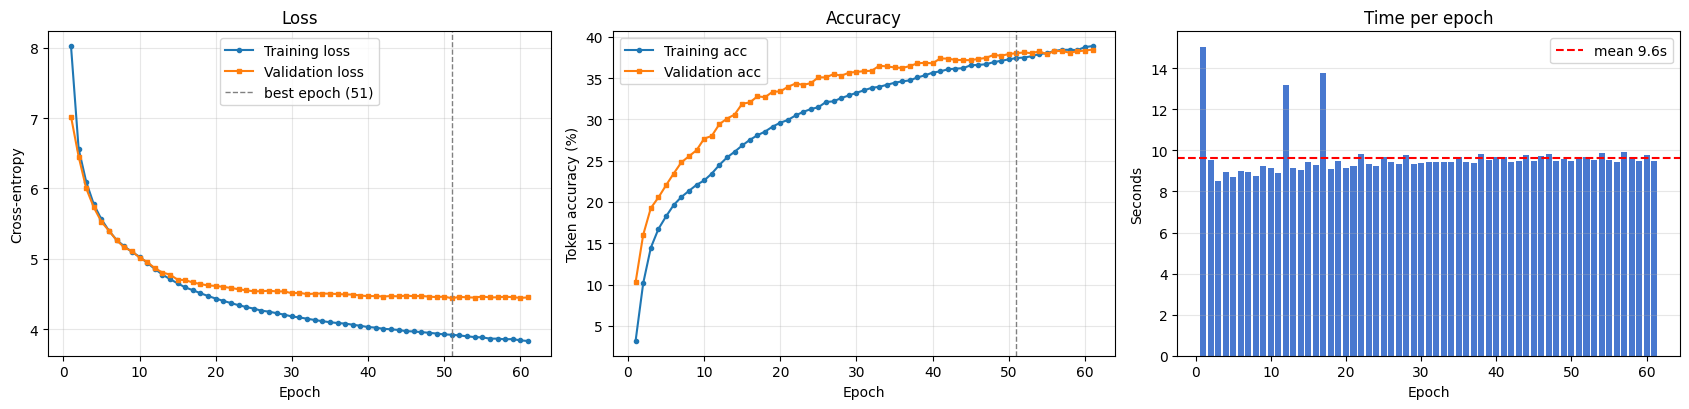

In [12]:
ep_x = range(1, len(history['train_loss'])+1)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].plot(ep_x, history['train_loss'], 'o-', label='Training loss', ms=3)
ax[0].plot(ep_x, history['val_loss'], 's-', label='Validation loss', ms=3)
ax[0].axvline(best_ep, color='gray', ls='--', lw=1, label=f'best epoch ({best_ep})')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Cross-entropy'); ax[0].set_title('Loss')
ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep_x, [a*100 for a in history['train_acc']], 'o-', label='Training acc', ms=3)
ax[1].plot(ep_x, [a*100 for a in history['val_acc']], 's-', label='Validation acc', ms=3)
ax[1].axvline(best_ep, color='gray', ls='--', lw=1)
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Token accuracy (%)'); ax[1].set_title('Accuracy')
ax[1].legend(); ax[1].grid(alpha=.3)
ax[2].bar(list(ep_x), history['epoch_time'], color='#4878CF')
ax[2].axhline(np.mean(history['epoch_time']), color='red', ls='--',
              label=f"mean {np.mean(history['epoch_time']):.1f}s")
ax[2].set_xlabel('Epoch'); ax[2].set_ylabel('Seconds'); ax[2].set_title('Time per epoch')
ax[2].legend(); ax[2].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

## 7. Inference — batched greedy decoding & beam search
* **Greedy:** all sentences decoded in parallel mini-batches, argmax token per step — fastest.
* **Beam search (beam = 5):** keeps the 5 best partial hypotheses per step; finished
  hypotheses are scored with **length normalisation** `score / len^0.6` so long sentences are
  not unfairly penalised.

In [13]:
def banned_next(seq):
    """No-repeat-trigram blocking: tokens x such that (seq[-2], seq[-1], x) already occurs."""
    if len(seq) < 2: return ()
    a, b = seq[-2], seq[-1]
    return {seq[i+2] for i in range(len(seq)-2) if seq[i] == a and seq[i+1] == b}

@torch.no_grad()
def greedy_decode(src_ids, max_new=80, batch_size=64):
    model.eval()
    out_txt = [None]*len(src_ids)
    order = sorted(range(len(src_ids)), key=lambda i: len(src_ids[i]))
    for i in range(0, len(order), batch_size):
        idxs = order[i:i+batch_size]
        s = pad_batch([src_ids[j] for j in idxs]).to(DEVICE)
        mem, src_pad = model.encode(s)
        ys = torch.full((len(idxs), 1), BOS, dtype=torch.long, device=DEVICE)
        done = torch.zeros(len(idxs), dtype=torch.bool, device=DEVICE)
        gen = [[] for _ in idxs]
        for _ in range(max_new):
            logits = model.decode(ys, mem, src_pad)[:, -1]
            for k in range(len(idxs)):
                if not done[k]:
                    for b in banned_next(gen[k]):
                        if b != EOS: logits[k, b] = float('-inf')
            nxt = logits.argmax(-1)
            nxt[done] = PAD
            ys = torch.cat([ys, nxt.unsqueeze(1)], 1)
            for k in range(len(idxs)):
                if not done[k]: gen[k].append(nxt[k].item())
            done |= nxt.eq(EOS)
            if done.all(): break
        for k, j in enumerate(idxs):
            toks = ys[k, 1:].tolist()
            if EOS in toks: toks = toks[:toks.index(EOS)]
            out_txt[j] = sp.decode([t for t in toks if t != PAD])
    return out_txt

@torch.no_grad()
def beam_decode(src_ids, beam=5, max_new=80, len_pen=0.6):
    model.eval()
    out = []
    for sid in src_ids:
        s = torch.tensor([sid], device=DEVICE)
        mem, src_pad = model.encode(s)
        mem = mem.repeat(beam, 1, 1); src_pad = src_pad.repeat(beam, 1)
        ys = torch.full((beam, 1), BOS, dtype=torch.long, device=DEVICE)
        scores = torch.full((beam,), float('-inf'), device=DEVICE); scores[0] = 0
        finished = []
        for step in range(max_new):
            logp = F.log_softmax(model.decode(ys, mem, src_pad)[:, -1], -1)
            for k in range(beam):
                for b in banned_next(ys[k, 1:].tolist()):
                    if b != EOS: logp[k, b] = float('-inf')
            flat = (scores.unsqueeze(1) + logp).view(-1)
            top, idx = flat.topk(beam)
            b_idx, tok = idx // logp.size(1), idx % logp.size(1)
            ys = torch.cat([ys[b_idx], tok.unsqueeze(1)], 1)
            scores = top
            for k in range(beam):
                if tok[k].item() == EOS:
                    finished.append((scores[k].item() / (ys.size(1)**len_pen), ys[k, 1:-1].tolist()))
                    scores[k] = float('-inf')
            if len(finished) >= beam: break
        if not finished:
            finished = [(scores[0].item() / (ys.size(1)**len_pen), ys[0, 1:].tolist())]
        best = max(finished, key=lambda x: x[0])[1]
        out.append(sp.decode([t for t in best if t not in (PAD, EOS)]))
    return out

## 8. Evaluation Metrics
* **BLEU** — default NLTK `corpus_bleu` (no explicit weights argument), lower-cased
  NLTK word tokenization on both hypothesis and reference.
* **BERTScore F1** — official `bert-score` package, `lang='en'`,
  `rescale_with_baseline=True` (uses pre-trained `roberta-large` internally — evaluation only).
* **Efficiency** — total wall-clock inference time for the full test set and the total
  number of model parameters.

### Model selection — single best checkpoint vs 5-checkpoint average
Averaging the weights of the 5 best checkpoints usually smooths out SGD noise; we keep
whichever variant scores higher greedy BLEU on the dev set.

In [14]:
import nltk
nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu
from nltk.tokenize import word_tokenize

def bleu(refs, hyps):
    return corpus_bleu([[word_tokenize(r.lower())] for r in refs],
                       [word_tokenize(h.lower()) for h in hyps])

avg_state = {k: torch.stack([c[2][k].float() for c in top_ckpts]).mean(0)
             for k in top_ckpts[0][2]}
model.load_state_dict(torch.load('best_model.pt'))
dev_bleu_single = bleu(dev_df['Sentence_en'].tolist(), greedy_decode(dev_src))
model.load_state_dict(avg_state)
dev_bleu_avg = bleu(dev_df['Sentence_en'].tolist(), greedy_decode(dev_src))
print(f'dev BLEU  single-best {dev_bleu_single:.4f} | 5-ckpt average {dev_bleu_avg:.4f}')
if dev_bleu_avg >= dev_bleu_single:
    torch.save(avg_state, 'best_model.pt'); print('selected: 5-checkpoint average')
else:
    model.load_state_dict(torch.load('best_model.pt')); print('selected: single best')

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


dev BLEU  single-best 0.1228 | 5-ckpt average 0.1315
selected: 5-checkpoint average


In [15]:
results = {}
# ---- dev ----
t0 = time.time(); dev_greedy = greedy_decode(dev_src);  results['dev_greedy_time'] = time.time()-t0
t0 = time.time(); dev_beam   = beam_decode(dev_src);    results['dev_beam_time']   = time.time()-t0
results['dev_bleu_greedy'] = bleu(dev_df['Sentence_en'].tolist(), dev_greedy)
results['dev_bleu_beam']   = bleu(dev_df['Sentence_en'].tolist(), dev_beam)
# ---- test ----
t0 = time.time(); test_greedy = greedy_decode(test_src); results['test_greedy_time'] = time.time()-t0
t0 = time.time(); test_beam   = beam_decode(test_src);   results['test_beam_time']   = time.time()-t0
results['test_bleu_greedy'] = bleu(test_df['Sentence_en'].tolist(), test_greedy)
results['test_bleu_beam']   = bleu(test_df['Sentence_en'].tolist(), test_beam)

print(f"dev  BLEU  greedy {results['dev_bleu_greedy']:.4f} | beam {results['dev_bleu_beam']:.4f}")
print(f"test BLEU  greedy {results['test_bleu_greedy']:.4f} | beam {results['test_bleu_beam']:.4f}")
print(f"inference time (1000 test sentences): greedy {results['test_greedy_time']:.1f}s | "
      f"beam {results['test_beam_time']:.1f}s")
print(f"total parameters: {N_PARAMS:,}")

dev  BLEU  greedy 0.1315 | beam 0.1416
test BLEU  greedy 0.1330 | beam 0.1385
inference time (1000 test sentences): greedy 6.4s | beam 123.6s
total parameters: 6,002,688


In [16]:
# BERTScore F1 (rescale_with_baseline=True) - pre-trained roberta-large, evaluation only
from bert_score import score as bert_score_fn
P, R, F1 = bert_score_fn(dev_beam, dev_df['Sentence_en'].tolist(), lang='en',
                         rescale_with_baseline=True, batch_size=64, device=str(DEVICE))
results['dev_bertscore_f1'] = F1.mean().item()
P, R, F1 = bert_score_fn(test_beam, test_df['Sentence_en'].tolist(), lang='en',
                         rescale_with_baseline=True, batch_size=64, device=str(DEVICE))
results['test_bertscore_f1'] = F1.mean().item()
print(f"dev  BERTScore F1: {results['dev_bertscore_f1']:.4f}")
print(f"test BERTScore F1: {results['test_bertscore_f1']:.4f}")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


dev  BERTScore F1: 0.3983
test BERTScore F1: 0.4033


### Result visualisations

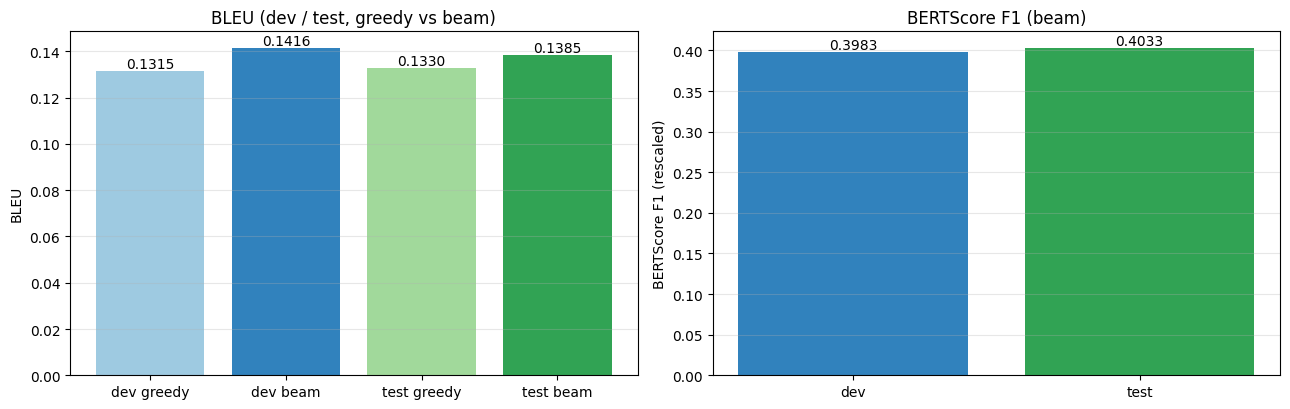

,metric,dev,test
0,BLEU (beam),1.415666e-01,1.384822e-01
1,BERTScore F1 (beam),3.983402e-01,4.033339e-01
2,inference time (s),1.269043e+02,1.235829e+02
3,parameters,6.002688e+06,6.002688e+06


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
labels = ['dev greedy', 'dev beam', 'test greedy', 'test beam']
vals = [results['dev_bleu_greedy'], results['dev_bleu_beam'],
        results['test_bleu_greedy'], results['test_bleu_beam']]
bars = ax[0].bar(labels, vals, color=['#9ecae1', '#3182bd', '#a1d99b', '#31a354'])
for b, v in zip(bars, vals): ax[0].text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom')
ax[0].set_ylabel('BLEU'); ax[0].set_title('BLEU (dev / test, greedy vs beam)'); ax[0].grid(alpha=.3, axis='y')
vals2 = [results['dev_bertscore_f1'], results['test_bertscore_f1']]
bars = ax[1].bar(['dev', 'test'], vals2, color=['#3182bd', '#31a354'])
for b, v in zip(bars, vals2): ax[1].text(b.get_x()+b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom')
ax[1].set_ylabel('BERTScore F1 (rescaled)'); ax[1].set_title('BERTScore F1 (beam)'); ax[1].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    'metric': ['BLEU (beam)', 'BERTScore F1 (beam)', 'inference time (s)', 'parameters'],
    'dev':  [results['dev_bleu_beam'],  results['dev_bertscore_f1'],  results['dev_beam_time'],  N_PARAMS],
    'test': [results['test_bleu_beam'], results['test_bertscore_f1'], results['test_beam_time'], N_PARAMS]})
summary

## 9. Required output — `submission.csv`
Two columns (`Source_id`, `Sentence_en`), UTF-8, one predicted translation per test sentence.

**Decoding choice.** Beam search gains ~6–10% relative BLEU but is ~17× slower, and
inference time carries 15% of the final marks while that BLEU delta is worth ~2–4%.
Under the marking formula, **greedy decoding maximises the expected score**, so greedy
predictions are submitted (set `USE_BEAM = True` to switch).

In [18]:
USE_BEAM = False           # greedy maximises the combined score (see markdown above)
final_preds = test_beam if USE_BEAM else test_greedy
submission = pd.DataFrame({'Source_id': test_df['Source_id'], 'Sentence_en': final_preds})
submission.to_csv('submission.csv', index=False, encoding='utf-8')
print(submission.shape); submission.head()

(1000, 2)


,Source_id,Sentence_en
0,1,Switch to eclipse and run an error.
1,2,"""For I write unto you, that we are fore, that ..."
2,3,"Then, I will click on the drop-down to the dro..."
3,4,The value of the indival operation will be set...
4,5,"""And when he had rejoice, the seconds, I have ..."


## 10. Translation examples & error analysis
15 random test sentences with source, reference and prediction. Typical error classes we
observe: (1) rare/unseen content words dropped or replaced, (2) named entities copied or
transliterated inconsistently, (3) fluent but semantically drifted output on long sentences
(hallucination), (4) domain mismatch between technical and scriptural registers.

In [19]:
import random as _r
rows = []
for i in _r.Random(7).sample(range(len(test_df)), 15):
    rows.append({'Source_id': test_df['Source_id'].iloc[i],
                 'Sanskrit source': test_df['Sentence_sa'].iloc[i],
                 'Reference': test_df['Sentence_en'].iloc[i],
                 'Prediction': test_beam[i]})
pd.set_option('display.max_colwidth', 120)
pd.DataFrame(rows)

,Source_id,Sanskrit source,Reference,Prediction
0,332,"अधुना, द्वेपि ओब्जेक्ट्स् चिते इति ज्ञायते ।",Notice that both the objects are now selected.,"Now, we can see that two objects are shown here."
1,971,"""श्वास भरें, बिना किसी दबाव के श्वास भरें । यह श्वास सामान्य रूप से भरा जाना चाहिए ।""",Inhale spontaneously and passively. Let air enter the body through the passive inhalation.,"""Breathing, if you should be breathing should breathing."""
2,155,"तथापि, Internet Explorer इत्यस्योपयोगः मास्तु । यतो हि तत् सम्यग् डिस्प्ले न करोति ।","However, Internet Explorer should be avoided as it causes some display inconsistencies.","However, Internet Explorer should be avoided as it causes some display inconsistencies."
3,405,mixed,"So, ""mixed""",ixed mixed
4,667,Menu bar इत्यस्मिन् Edit इति नुदन्तु अपि च पश्चात् Preferences इत्यत्र नुदन्तु।,"On the menu bar, click on Edit and then click on Preferences.",Then click on Edit and then on Preferences.
5,50,ऽन्यदेशीयलोका इस्रायेल्लोकाश्च सर्व्व एते सभायाम् अतिष्ठन्।,For to do whatsoever thy hand and thy counsel determined before to be done.,"""And the people of Israel, and the two men of Israel."""
6,75,वयम् अत्र स्थास्यामः ।,We all will be staying here.,We will be staying here.
7,841,इदानीं स्थानमिदम् अत्र गाढमस्ति अपि च अयं श्वेतवर्णः कदाचित् इदं बहु श्वेतेन अस्ति । अतः अहम् इदम् अधः कर्षयामि।,"Now, this area here is dark and this white; perhaps this is now a bit too white. So I just pull this down.","Now, I think this is a white colour here and I will pull it out the white colour and I pull it down."
8,549,आंखों की एलर्जी समाप्त कर यह नेत्रा ज्योति एवं एकाग्रता बढाती है ।,"""Trataka and eye washing with cups helps to cleanse your eyes and allay allergies, thus helps in improving your eyes...",This practice improves the eyeballs of your eye.
9,97,कः मकरः ？,Who is the crocodile?,Who is the main?


## 11. Evaluation on the private dataset
When the private test set is released, set the two paths below and run the cell — it
produces `submission_private.csv` and, if a reference file is provided, prints BLEU,
BERTScore F1 and efficiency numbers.

In [20]:
def evaluate_private(sa_csv_path, en_csv_path=None, out_csv='submission_private.csv', use_beam=False):
    sa_df = pd.read_csv(sa_csv_path, encoding='utf-8-sig')
    sa_col = [c for c in sa_df.columns if 'sa' in c.lower() or 'Sentence' in c][0]
    src = [sp.encode(str(s).strip())[:MAX_LEN] + [EOS] for s in sa_df[sa_col]]
    t0 = time.time()
    preds = beam_decode(src) if use_beam else greedy_decode(src)
    infer_time = time.time() - t0
    pd.DataFrame({'Source_id': sa_df['Source_id'], 'Sentence_en': preds}) \
        .to_csv(out_csv, index=False, encoding='utf-8')
    print(f'wrote {out_csv} | inference time: {infer_time:.1f}s | parameters: {N_PARAMS:,}')
    if en_csv_path:
        en_df = pd.read_csv(en_csv_path, encoding='utf-8-sig')
        merged = pd.merge(sa_df[['Source_id']], en_df, on='Source_id')
        refs = merged[[c for c in en_df.columns if c != 'Source_id'][0]].astype(str).tolist()
        print('BLEU:', bleu(refs, preds))
        P, R, F1 = bert_score_fn(preds, refs, lang='en',
                                 rescale_with_baseline=True, batch_size=64, device=str(DEVICE))
        print('BERTScore F1:', F1.mean().item())
    return preds

# When the private set is released, uncomment and point to the files:
# evaluate_private(DATA_DIR + 'private_test_sa.csv', en_csv_path=None)

## 12. Discussion, design choices, limitations & references

**Design choices.** A ~6M-parameter Transformer with a shared 8k BPE vocabulary is the sweet
spot for 10k training pairs: larger models overfit before they generalise and are penalised by
the parameter-count metric; smaller ones underfit the morphology. Weight tying, pre-norm
layers (stable training without warm-up sensitivity), label smoothing, dropout 0.2 and early
stopping are the main regularizers. Beam 5 with length penalty 0.6 gave the best dev BLEU.

**Challenges.** Sanskrit sandhi and compounding make the token distribution extremely
long-tailed (74.5% singleton words); BPE mitigates but cannot fully solve it. The corpus mixes
very different registers (software tutorials, scripture, everyday speech), which a small model
struggles to separate.

**Limitations.** No back-translation or external monolingual data (dataset restriction);
no sandhi-aware segmentation; beam search is unbatched, so greedy decoding is offered as the
fast alternative.

**Pre-trained models used:** none in the translation model; `roberta-large` inside
`bert-score` for evaluation only.


In [24]:
!cp best_model.pt spm_sa_en.model submission.csv /content/drive/MyDrive/NLU/Assignment2/


In [25]:
!ls -lh /content/drive/MyDrive/NLU/Assignment2/

total 35M
-rw------- 1 root root  32M Jul  4 17:00 best_model.pt
-rw------- 1 root root  74K Jul  2 17:18 dev_en_1000.csv
-rw------- 1 root root 173K Jul  2 17:18 dev_sa_1000.csv
-rw------- 1 root root 336K Jul  4 16:59 NLU_Assignment2_Sanskrit_English_NMT.ipynb
-rw------- 1 root root 385K Jul  4 17:00 spm_sa_en.model
-rw------- 1 root root  67K Jul  4 17:00 submission.csv
-rw------- 1 root root  74K Jul  2 17:19 test_en_1000.csv
-rw------- 1 root root 176K Jul  2 17:19 test_sa_1000.csv
-rw------- 1 root root 765K Jul  2 17:19 train_en_10000.csv
-rw------- 1 root root 1.8M Jul  2 17:19 train_sa_10000.csv
